
Testing: Neurons=64, LR=0.01, Layers=1
1/1 [==============================] - 0s 441ms/step
MAPE: 0.07%

Testing: Neurons=64, LR=0.01, Layers=2
1/1 [==============================] - 1s 776ms/step
MAPE: 0.04%

Testing: Neurons=64, LR=0.001, Layers=1
1/1 [==============================] - 0s 417ms/step
MAPE: 0.04%

Testing: Neurons=64, LR=0.001, Layers=2
1/1 [==============================] - 1s 772ms/step
MAPE: 0.04%

Testing: Neurons=128, LR=0.01, Layers=1
1/1 [==============================] - 0s 434ms/step
MAPE: 0.04%

Testing: Neurons=128, LR=0.01, Layers=2
1/1 [==============================] - 1s 801ms/step
MAPE: 0.04%

Testing: Neurons=128, LR=0.001, Layers=1
1/1 [==============================] - 0s 415ms/step
MAPE: 0.06%

Testing: Neurons=128, LR=0.001, Layers=2
1/1 [==============================] - 1s 728ms/step
MAPE: 0.05%

Testing: Neurons=256, LR=0.01, Layers=1
1/1 [==============================] - 0s 471ms/step
MAPE: 0.06%

Testing: Neurons=256, LR=0.01, Layers=2
1/1 [

C:\Users\E124796\AppData\Local\Temp\2\ipykernel_7188\3275632217.py:174: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(best_model, 'best_lstm_model.h5')


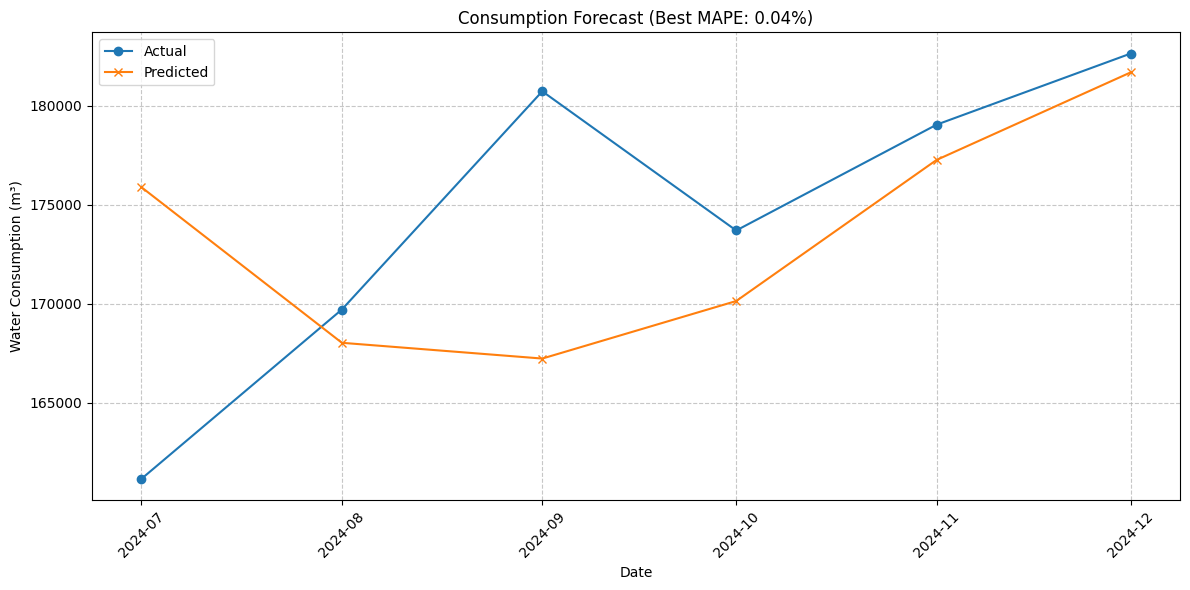

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import tensorflow as tf
import os
import random
from keras.regularizers import L1L2
from keras.models import save_model

# ==========================================
# Reproducibility Configuration (Frozen Seeds)
# ==========================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Custom function to calculate MAPE as loss
def mape_loss(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100

# Function to create datasets (Sliding Window)
def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        y_val = data[i + look_back]
        Y.append(y_val)
    return np.array(X), np.array(Y)

# Function to build a dynamic LSTM model
def build_dynamic_model(input_shape, neurons=100, learning_rate=0.01, n_layers=2):
    model = Sequential()
    
    # Add the first LSTM layer
    model.add(LSTM(
        neurons, 
        return_sequences=(n_layers > 1), 
        input_shape=input_shape,
        kernel_regularizer=L1L2(l1=1e-5, l2=1e-4)
    ))
    model.add(Dropout(0.2))
    
    # Add intermediate LSTM layers
    for i in range(1, n_layers):
        return_seq = (i != n_layers - 1)
        model.add(LSTM(
            neurons // (2 ** i),  
            return_sequences=return_seq,
            kernel_regularizer=L1L2(l1=1e-5, l2=1e-4)
        ))
        model.add(Dropout(0.2))
    
    # Final dense layers
    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss=mape_loss, optimizer=optimizer)
    return model

# Main prediction and plotting function
def prever_e_plotar(caminho_arquivo):
    # Load and prepare data
    df = pd.read_csv(caminho_arquivo, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    
    # Add numerical index to facilitate data splitting
    df_aggregated['index'] = range(len(df_aggregated))
    
    # Normalization
    scaler = MinMaxScaler(feature_range=(0, 1))
    ts_scaled = scaler.fit_transform(df_aggregated[['HCLQTCON']]).flatten()
    
    # Find cutoff indices based on specific dates
    train_end_idx = df_aggregated[df_aggregated['AM_REFERENCIA'] <= pd.to_datetime('2023-12-31')]['index'].max()
    test_start_idx = df_aggregated[df_aggregated['AM_REFERENCIA'] >= pd.to_datetime('2024-01-01')]['index'].min()
    test_end_idx = df_aggregated[df_aggregated['AM_REFERENCIA'] <= pd.to_datetime('2024-12-31')]['index'].max()
    
    # Train-test split
    train = ts_scaled[:train_end_idx+1]
    test = ts_scaled[test_start_idx:test_end_idx+1]
    
    # Create datasets (6 months look-back)
    look_back = 6
    X_train, Y_train = create_dataset(train, look_back)
    X_test, Y_test = create_dataset(test, look_back)
    
    if len(X_train) == 0 or len(X_test) == 0:
        raise ValueError("Insufficient data for training or testing.")

    # Reshape to (samples, time steps, features)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Hyperparameters for grid search
    params_grid = {
        'neurons': [64, 128, 256],
        'learning_rate': [0.01, 0.001],
        'n_layers': [1, 2],
        'epochs': [50, 100, 200],
        'batch_size': [1, 4]
    }

    best_mape = float('inf')
    best_model = None
    best_params = {}
    best_scaler = None

    # Search for the best hyperparameter combination
    for neurons in params_grid['neurons']:
        for lr in params_grid['learning_rate']:
            for n_layers in params_grid['n_layers']:
                print(f"\nTesting: Neurons={neurons}, LR={lr}, Layers={n_layers}")
                
                model = build_dynamic_model(
                    input_shape=(X_train.shape[1], 1),
                    neurons=neurons,
                    learning_rate=lr,
                    n_layers=n_layers
                )
                
                early_stop = EarlyStopping(monitor='loss', patience=10)
                
                history = model.fit(
                    X_train, Y_train,
                    epochs=params_grid['epochs'][1],
                    batch_size=params_grid['batch_size'][0],
                    verbose=0,
                    callbacks=[early_stop]
                )
                
                predictions = model.predict(X_test)
                predictions = scaler.inverse_transform(predictions).flatten()
                Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1)).flatten()
                
                mape_value = mape(Y_test_inv, predictions)
                print(f"MAPE: {mape_value:.2f}%")
                
                if mape_value < best_mape:
                    best_mape = mape_value
                    best_model = model
                    best_params = {
                        'neurons': neurons,
                        'learning_rate': lr,
                        'n_layers': n_layers,
                        'epochs': len(history.history['loss'])
                    }
                    best_scaler = scaler

    # Final results output
    print("\nBest Parameters Found:")
    print(best_params)
    print(f"Best MAPE: {best_mape:.2f}%")

    # Save the best model and scaler
    save_model(best_model, 'best_lstm_model.h5')
    import joblib
    joblib.dump(best_scaler, 'scaler_itapua.save')
    print("Model and scaler saved successfully!")

    # Final predictions using the best model
    final_predictions = best_model.predict(X_test)
    final_predictions = best_scaler.inverse_transform(final_predictions.reshape(-1, 1)).flatten()

    # Get dates corresponding to the test period
    test_dates = df_aggregated.iloc[test_start_idx+look_back:test_end_idx+1]['AM_REFERENCIA'].values
    
    # Comparison DataFrame
    comparison_df = pd.DataFrame({
        'Date': test_dates,
        'Actual Value': best_scaler.inverse_transform(Y_test.reshape(-1, 1)).flatten(),
        'Predicted Value': final_predictions
    })

    print("\nFinal Comparison Table:")
    print(comparison_df)

    # Plotting results
    plt.figure(figsize=(12, 6))
    plt.plot(comparison_df['Date'], comparison_df['Actual Value'], label='Actual', marker='o')
    plt.plot(comparison_df['Date'], comparison_df['Predicted Value'], label='Predicted', marker='x')
    plt.title(f"Consumption Forecast (Best MAPE: {best_mape:.2f}%)")
    plt.xlabel("Date")
    plt.ylabel("Water Consumption (m³)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Main Execution
if __name__ == "__main__":
    path = r'..'
    caminho_arquivo = os.path.join(path, 'includes\\Tabela_consumo_Itapua_120m.csv')
    prever_e_plotar(caminho_arquivo)